Nama: Dimas Satria Prayoga

# Import Library

In [1]:
# ==============================
# 📊 Library Manipulasi Data
# ==============================
import numpy as np  # Library dasar untuk komputasi numerik (array, matriks, dll)
import pandas as pd  # Library untuk analisis dan manipulasi data berbasis tabel (DataFrame)

# ==============================
# 📈 Library Visualisasi
# ==============================
import matplotlib.pyplot as plt  # Untuk membuat visualisasi grafik (plot, chart, dll)
from mpl_toolkits.axes_grid1 import ImageGrid  # Untuk menampilkan beberapa gambar dalam satu grid
import seaborn as sns  # Untuk visualisasi statistik yang lebih menarik dan informatif

# ==============================
# 🖥️ Library Sistem & File
# ==============================
import kagglehub  # Untuk mengakses dan mengunduh dataset dari Kaggle
import os  # Untuk berinteraksi dengan sistem operasi (file, folder, path, dll)
import time  # Untuk mengatur atau menghitung waktu proses
from google.colab import files  # Untuk upload dan download file di Google Colab

# ==============================
# 🤖 Library Machine Learning (Scikit-learn)
# ==============================
from sklearn.model_selection import train_test_split  # Membagi data menjadi train dan test
from sklearn.metrics import accuracy_score  # Menghitung akurasi model klasifikasi
from sklearn.metrics import classification_report  # Menampilkan laporan evaluasi (precision, recall, f1-score)
from sklearn.metrics import confusion_matrix  # Membuat confusion matrix untuk evaluasi model
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# ==============================
# 🧠 Deep Learning Framework
# ==============================
import tensorflow as tf  # Library utama untuk deep learning dan komputasi numerik
import keras  # API high-level untuk membangun model deep learning (bagian dari TensorFlow)

# ==============================
# 🖼️ Preprocessing Citra
# ==============================
# Untuk membuat generator data gambar dengan augmentasi secara real-time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Utility tambahan untuk preprocessing gambar
from tensorflow.keras.preprocessing import image
# Untuk memuat gambar ke format PIL (Python Imaging Library)
from tensorflow.keras.preprocessing.image import load_img
# Mengubah gambar (PIL) menjadi array NumPy
from tensorflow.keras.preprocessing.image import img_to_array
# Fungsi preprocessing khusus untuk model EfficientNetV2
from tensorflow.keras.applications.inception_v3 import preprocess_input # Ganti
import cv2 # Library OpenCV untuk pengolahan citra (image processing)
from PIL import Image # Library untuk membuka, memanipulasi, dan menyimpan gambar

# ==============================
# 🏗️ Arsitektur Model (Pretrained CNN)
# ==============================
from tensorflow.keras.applications import InceptionV3 # Ganti
from keras.callbacks import EarlyStopping, ModelCheckpoint
# Model CNN pretrained yang ringan dan efisien
from tensorflow.keras.layers import BatchNormalization
# Layer untuk menstabilkan distribusi data (mean ~0, std ~1)
from tensorflow.keras.layers import Dropout
# Layer untuk mengurangi overfitting dengan mematikan neuron secara acak
from tensorflow.keras.layers import Dense
# Layer fully connected (neural network biasa)
from tensorflow.keras.models import Model
# Untuk membangun model deep learning (menggabungkan layer)
from tensorflow.keras.optimizers import Adamax
# Optimizer (varian Adam) untuk proses training model

# Dataset Retrieval

In [2]:
# Download latest version
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print("Path to dataset files:", path)
# Menentukan path utama folder
parent_dir = os.path.join(path, "cell_images")

# Mendefinisikan path spesifik untuk setiap kategori tumor di dalam folder training
parasitized_cases_path = os.path.join(parent_dir, "Parasitized")
uninfected_cases_path = os.path.join(parent_dir, "Uninfected")

# Menampilkan lokasi direktori tiap kelas (untuk verifikasi)
print(f"\nParasitized Cases Path Train set: {parasitized_cases_path}")
print(f"Uninfected Cases Path Train set: {uninfected_cases_path}")

# Menghitung dan menampilkan jumlah file gambar dalam setiap kategori training
print("\nThe number of data items in each path in the training set :")
print(f"Parasitized cases: {len(os.listdir(parasitized_cases_path))} images")
print(f"Uninfected cases: {len(os.listdir(uninfected_cases_path))} images")

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria

Parasitized Cases Path Train set: /kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized
Uninfected Cases Path Train set: /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected

The number of data items in each path in the training set :
Parasitized cases: 13780 images
Uninfected cases: 13780 images


# Data Preparation

In [3]:
# Inisialisasi path dan list
data_dirs = [parent_dir]
filepaths = []
labels = []

# Loop folder utama
for data_dir in data_dirs:
  folds = os.listdir(data_dir)

  for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    # Pastikan foldpath adalah direktori sebelum listdir
    if os.path.isdir(foldpath):
      filelist = os.listdir(foldpath)
      for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Konversi ke pandas series
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

# Gabungkan jadi DataFrame
df = pd.concat([Fseries, Lseries], axis=1)

# Path yang ingin dihapus (berdasarkan path spesifik sebelumnya)
path_to_remove = [
    '/root/.cache/kagglehub/datasets/iarunava/cell-images-for-detecting-malaria/versions/1/cell_images/cell_images/Uninfected',
    '/root/.cache/kagglehub/datasets/iarunava/cell-images-for-detecting-malaria/versions/1/cell_images/cell_images/Parasitized'
]
df = df[~df['filepaths'].isin(path_to_remove)]

# Hapus data yang berlabel cell_images
df = df[df['labels'] != 'cell_images'].reset_index(drop=True)

display(df)

,filepaths,labels
0,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
1,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
2,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
3,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
4,/kaggle/input/cell-images-for-detecting-malari...,Uninfected
...,...,...
27555,/kaggle/input/cell-images-for-detecting-malari...,Parasitized
27556,/kaggle/input/cell-images-for-detecting-malari...,Parasitized
27557,/kaggle/input/cell-images-for-detecting-malari...,Parasitized
27558,/kaggle/input/cell-images-for-detecting-malari...,Parasitized


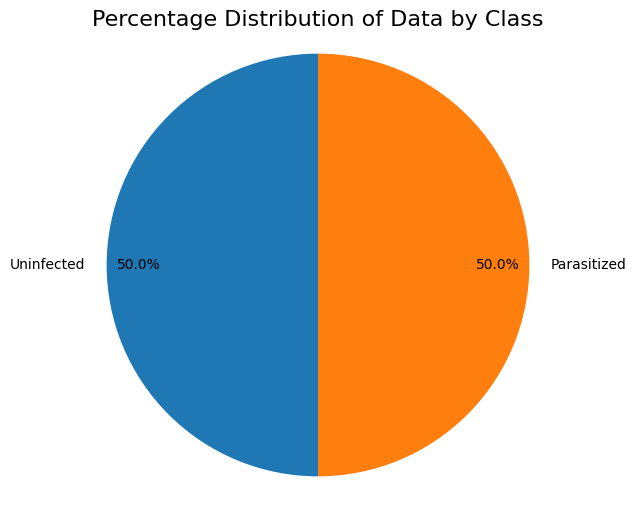

In [4]:
# Menampilkan distribusi jumlah data tiap kelas dalam bentuk pie chart (diagram lingkaran)
class_counts = df['labels'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Data by Class', fontsize=16)
plt.axis('equal')
plt.show()

# Data Preprocessing

In [5]:
# Pembagian: 70% Latih, 30% Sisa (untuk Val + Tes)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# Parameter ini memastikan bahwa proporsi kelas sama seperti pada data asli.
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("Val df shape:", val_df.shape)

Train df shape: (19292, 2)
Test df shape: (4134, 2)
Val df shape: (4134, 2)


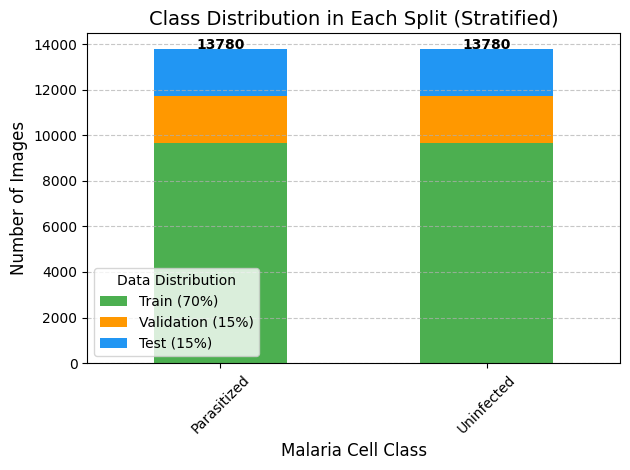

In [6]:
# Hitung jumlah data per kelas di setiap split
train_counts = train_df['labels'].value_counts().sort_index()
val_counts = val_df['labels'].value_counts().sort_index()
test_counts = test_df['labels'].value_counts().sort_index()

# Siapkan Data untuk Plotting
df_plot = pd.DataFrame({
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts,
})

# Membuat Diagram Batang
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Class Distribution in Each Split (Stratified)", fontsize=14)
plt.xlabel("Malaria Cell Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Data Distribution")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap batang
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Menampilkan jumlah data per kelas untuk setiap split (Train, Validation, Test)
df_total = df_plot.copy()
df_total["Total"] = df_plot.sum(axis=1)
display(df_total)

,Train (70%),Validation (15%),Test (15%),Total
labels,,,,
Parasitized,9646,2067,2067,13780
Uninfected,9646,2067,2067,13780


# Data Generator (Augmentasi & Loading)

In [8]:
# Hyperparameter yang menentukan jumlah data yang diproses dalam satu iterasi
batch_size = 128
# Ukuran gambar yang akan digunakan (harus sesuai dengan input model)
target_size = (224, 224)

# Function to check if a file is a valid image
def is_valid_image(filepath):
  try:
    # Attempt to open the image to verify its validity
    with Image.open(filepath) as img:
        img.verify() # Verify if it's a valid image
    return True
  except Exception:
    return False

# Filter out invalid image file paths from the dataframes
train_df = train_df[train_df['filepaths'].apply(is_valid_image)]
val_df = val_df[val_df['filepaths'].apply(is_valid_image)]
test_df = test_df[test_df['filepaths'].apply(is_valid_image)]

# Membuat generator data untuk training dengan augmentasi (penambahan variasi data)
train_datagen = ImageDataGenerator(
  # Fungsi preprocessing sesuai dengan model yang digunakan
  preprocessing_function=preprocess_input,
  rotation_range=20, # Rotasi gambar secara acak hingga \u00b120 derajat
  width_shift_range=0.05, # Pergeseran gambar secara horizontal
  height_shift_range=0.05, # Pergeseran gambar secara vertikal
  shear_range=0.05, # Transformasi kemiringan untuk membuat variasi sudut pandang
  zoom_range=0.05, # Zoom in/out secara acak hingga 5%
  horizontal_flip=True, # Membalik gambar secara horizontal secara acak
  fill_mode="nearest" # Mengisi piksel kosong hasil transformasi dengan nilai terdekat
)

# Membuat generator data untuk validasi, hanya preprocessing
val_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk testing, hanya preprocessing
test_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk Training dari dataframe
train_generator = train_datagen.flow_from_dataframe(
  dataframe = train_df, # DataFrame yang berisi path gambar dan label
  x_col = "filepaths", # Kolom yang berisi lokasi file gambar
  y_col = "labels", # Kolom yang berisi label (target/output)
  target_size = target_size, # Mengubah ukuran gambar sesuai input model
  color_mode = 'rgb', # Menggunakan 3 channel warna (RGB)
  class_mode = "categorical", # Digunakan untuk klasifikasi multi-kelas
  batch_size = batch_size, # Jumlah gambar dalam satu batch
  shuffle = True, # Shuffle the data order every epoch
  seed = 42)

# Membuat generator data untuk Testing dari dataframe
validation_generator = val_datagen.flow_from_dataframe(
  dataframe = val_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar evaluasi konsisten dan adil
  seed = 42)

# Membuat generator data untuk Testing dari dataframe
test_generator = test_datagen.flow_from_dataframe(
  dataframe = test_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar hasil evaluasi sesuai urutan asli
  seed = 42)

Found 19290 validated image filenames belonging to 2 classes.
Found 4134 validated image filenames belonging to 2 classes.
Found 4134 validated image filenames belonging to 2 classes.


# Exploratory Data Analysis (EDA)

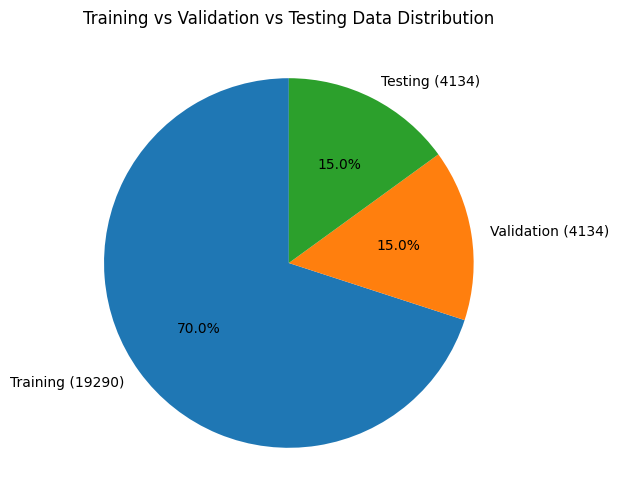

In [9]:
# Memvisualisasikan proporsi jumlah data pada dataset dalam bentuk pie chart (diagram lingkaran).
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Testing ({counts[2]})']
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Training vs Validation vs Testing Data Distribution")
plt.show()

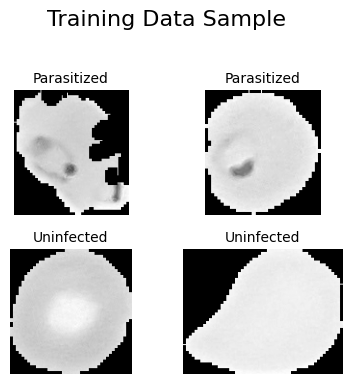

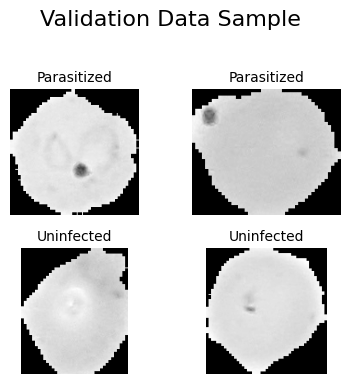

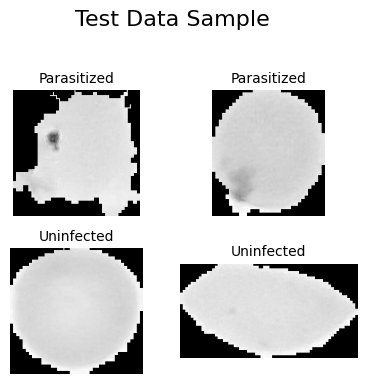

In [10]:
# Menampilkan beberapa contoh gambar dari setiap kelas (label) pada dataset dalam bentuk grid (tabel gambar)
# Menentukan jumlah gambar per kelas
num_images_per_class = 2

# Mengambil label kelas
class_labels = list(train_generator.class_indices.keys())

# Menyusun dataset yang akan ditampilkan
datasets = [
  (train_df, "Training Data Sample"),
  (val_df, "Validation Data Sample"),
  (test_df, "Test Data Sample")
]

# Loop untuk setiap dataset
for current_df, title in datasets:
  # Membuat canvas gambar
  plt.figure(figsize=(num_images_per_class * 2, len(class_labels) * 2))
  plt.suptitle(title, fontsize=16)

  # Loop tiap kelas
  for i, label in enumerate(class_labels):
    # Ambil filepath berdasarkan kelas
    class_filepaths = current_df[current_df['labels'] == label]['filepaths'].values

    # Random sampling gambar
    if len(class_filepaths) > 0:
      sampled_filepaths = np.random.choice(class_filepaths, min(num_images_per_class, len(class_filepaths)), replace=False)
    else:
      sampled_filepaths = []

    # Menampilkan gambar
    for j, filepath in enumerate(sampled_filepaths):
      # Posisis subplot
      plt.subplot(len(class_labels), num_images_per_class, i * num_images_per_class + j + 1)
      # Membaca gambar dalam grayscale dan menampilkan
      img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read image as grayscale
      plt.imshow(img, cmap='gray') # Display with 'gray' colormap
      # Tambahkan label
      plt.title(f"{label}", fontsize=10)
      plt.axis('off')

  # Rapikan Layout & Tampilkan hasil
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


# Model Creation (InceptionV3)

In [11]:
def build_InceptionV3_model():
  # Instantiates the InceptionV3 architecture.
  base_model = keras.applications.InceptionV3(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) InceptionV3.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(224, 224, 3),
    # 2 Class pada data penyakit Skin Cancer
    classes = 2,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
  )

  # 🔥 Fine-tuning: freeze sebagian layer
  for layer in base_model.layers[:-30]:
    layer.trainable = False

  # Sisakan layer atas tetap trainable
  for layer in base_model.layers[-30:]:
    layer.trainable = True

  # Menyusun arsitektur model
  model = keras.models.Sequential([
    # Feature extractor dari DenseNet
    base_model,
    # Global average pooling operation untuk 2D data.
    keras.layers.GlobalAveragePooling2D(),
    # Fully connected layer untuk pembelajaran pola penyakit
    keras.layers.Dense(256, activation='relu'),
    # Menstabilkan distribusi aktivasi
    keras.layers.BatchNormalization(),
    # Mengurangi overfitting
    keras.layers.Dropout(0.3),
    # Output layer (2 kelas)
    keras.layers.Dense(2, activation='softmax')
  ])

  return model

# Panggil fungsi untuk membuat model
InceptionV3_model = build_InceptionV3_model()
# Tampilkan ringkasan arsitektur model
InceptionV3_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,866 (85.18 MB)

 Trainable params: 5,681,602 (21.67 MB)

 Non-trainable params: 16,647,264 (63.50 MB)

# Tuning Hyperparameter 1

In [ ]:
# --- Inisialisasi Parameter ---
# Learning rate mengontrol seberapa besar model mengubah bobotnya setiap kali belajar
learning_rate = 0.01
# Epochs adalah jumlah total pengulangan (iterasi) model mempelajari seluruh dataset
epochs = 20

# --- Konfigurasi Optimizer ---
# Menggunakan Adamax, variasi dari optimizer Adam yang lebih stabil untuk model besar
optimizer = Adamax(learning_rate=learning_rate)

# --- Kompilasi Model ---
# Menyiapkan model sebelum dilatih dengan menentukan :
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# --- Proses Pelatihan (Training) ---
# Melatih model menggunakan data dari train_generator
# Selama proses ini, model juga akan diuji secara berkala menggunakan validation data
# Hasilnya disimpan di variabel 'history' untuk dianalisis grafiknya nanti
history1 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8845 - loss: 0.3362
Epoch 1: val_accuracy improved from None to 0.94630, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.9160 - loss: 0.2302 - val_accuracy: 0.9463 - val_loss: 0.1540
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9403 - loss: 0.1629
Epoch 2: val_accuracy did not improve from 0.94630
151/151 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.9430 - loss: 0.1578 - val_accuracy: 0.9448 - val_loss: 0.1541
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9476 - loss: 0.1416
Epoch 3: val_accuracy improved from 0.94630 to 0.95477, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.9473 - loss: 0.1435 - val_accuracy: 0.9548 - val_loss: 0.1337
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy

# Evaluation Metric 1

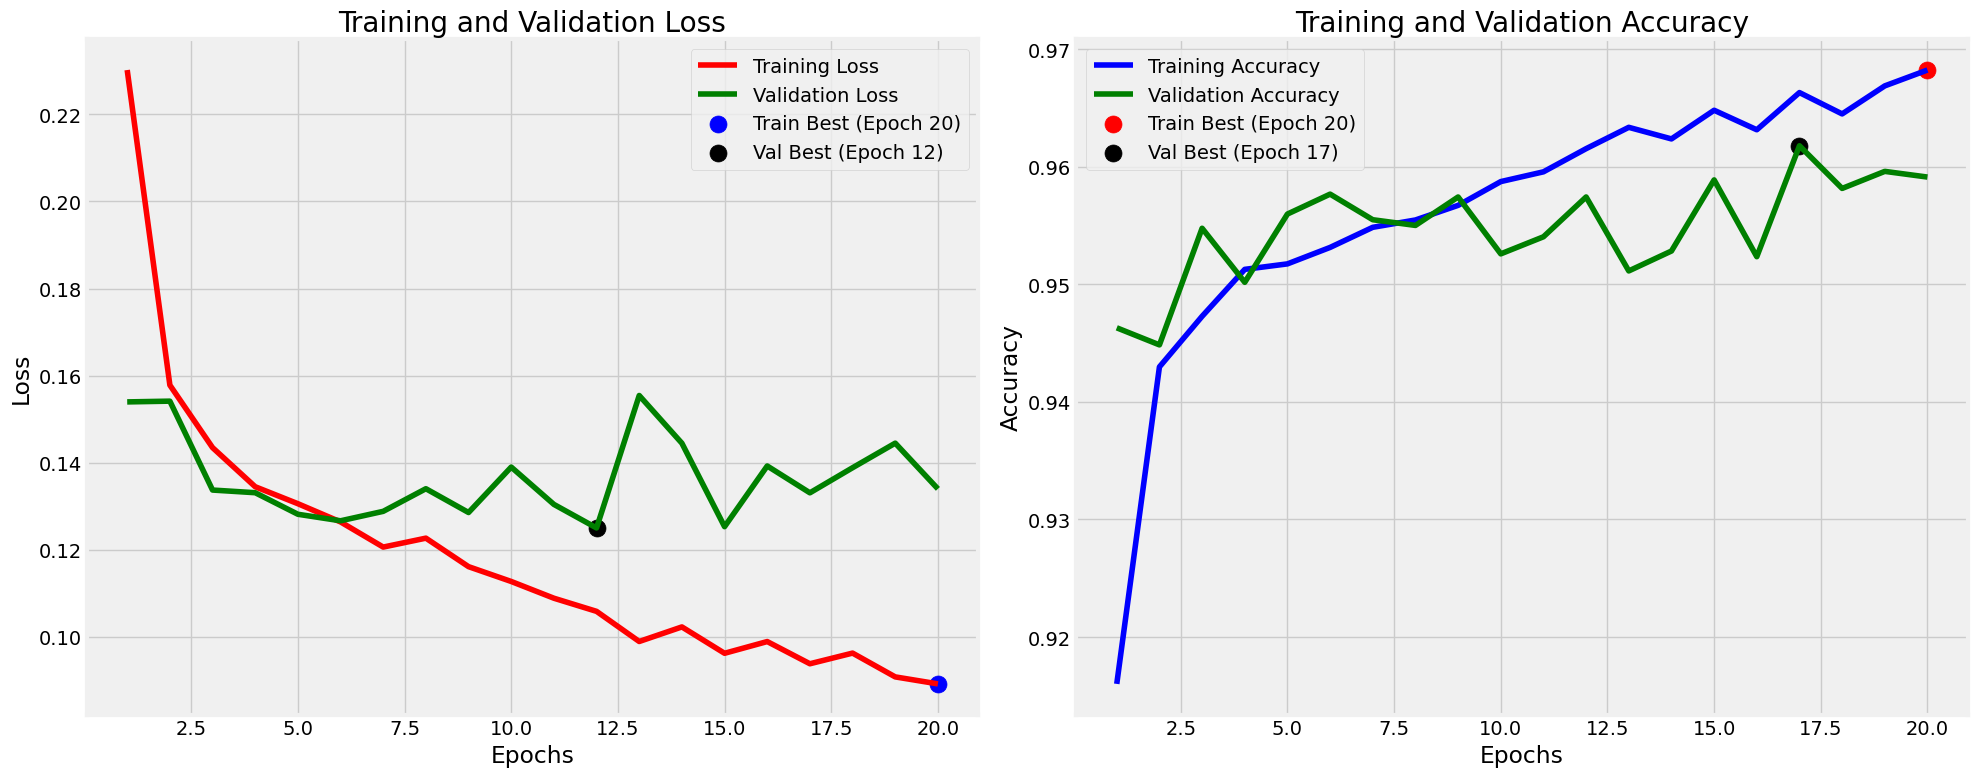

In [ ]:
# Ekstraksi data dari history
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Persiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Visualisasi Loss (Kerugian)
plt.subplot(1, 2, 1)
# Memplot garis Loss untuk data Training (warna merah 'r') dan Validation (warna hijau 'g')
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Menandai titik dengan Loss terendah menggunakan scatter plot (titik besar)
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)

# Memberi identitas pada grafik Loss
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Visualisasi Accuracy (Akurasi)
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Menandai titik dengan Akurasi tertinggi menggunakan scatter plot
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)

# Memberi identitas pada grafik Akurasi
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Menyesuaikan tata letak agar kedua grafik tidak saling tumpang tindih (rapi)
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 1 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 596ms/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.01
Epoch: 20

--- Informasi dari History 1 ---
Best Val Acc: 0.9618 (Epoch 17)
Testing Accuracy: 0.9557
Total Prediction Time: 27.29 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

 Parasitized      0.967     0.943     0.955      2067
  Uninfected      0.945     0.968     0.956      2067

    accuracy                          0.956      4134
   macro avg      0.956     0.956     0.956      4134
weighted avg      0.956     0.956     0.956      4134




--- Confusion Matrix ---


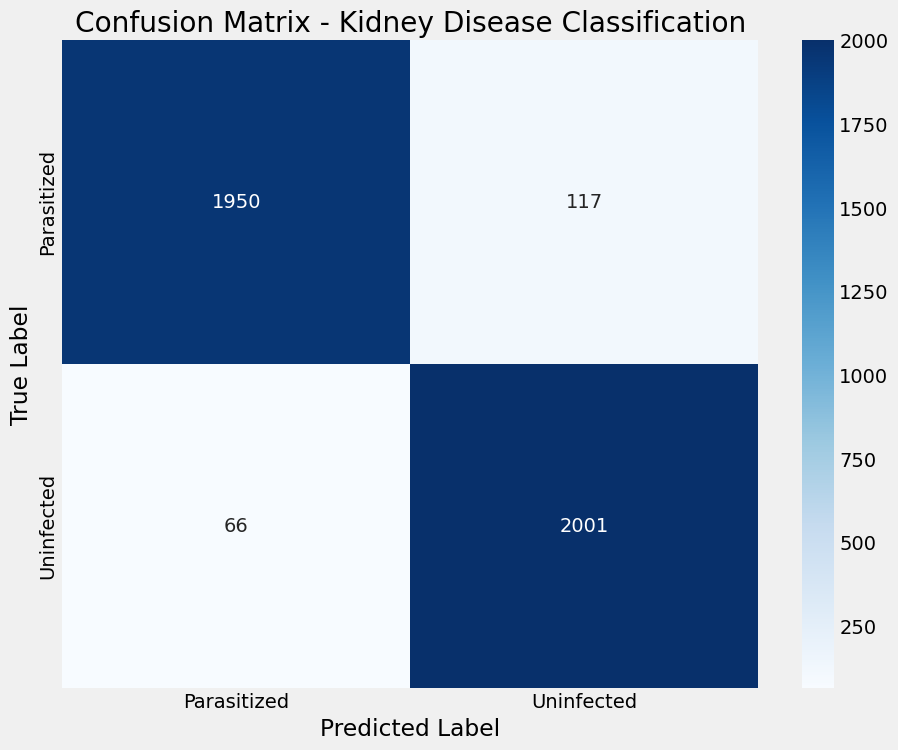

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 1 ---


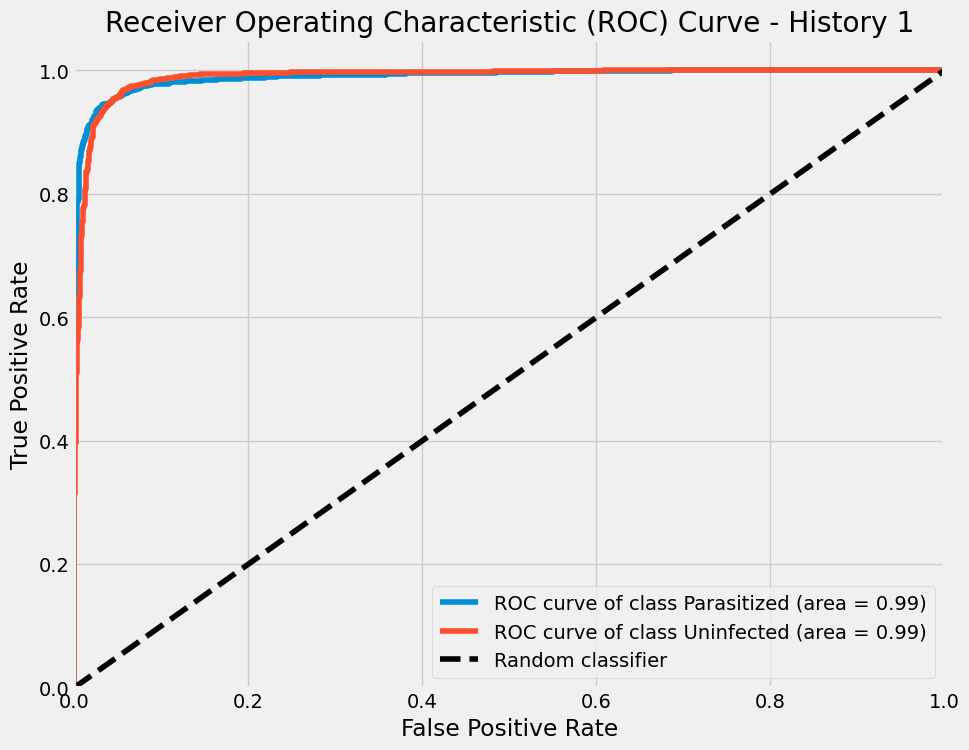

In [ ]:
print("\n--- ROC AUC for History 1 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 2

In [ ]:
# Parameter Initialization
learning_rate = 0.005
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# Trains the model for a fixed number of epochs (dataset iterations).
history2 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8891 - loss: 0.3164
Epoch 1: val_accuracy improved from None to 0.95138, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9194 - loss: 0.2213 - val_accuracy: 0.9514 - val_loss: 0.1529
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9439 - loss: 0.1555
Epoch 2: val_accuracy improved from 0.95138 to 0.95162, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.9445 - loss: 0.1541 - val_accuracy: 0.9516 - val_loss: 0.1434
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9464 - loss: 0.1436
Epoch 3: val_accuracy improved from 0.95162 to 0.95428, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.9486 - loss: 0.1414 - val_accurac

# Evaluation Metric 2

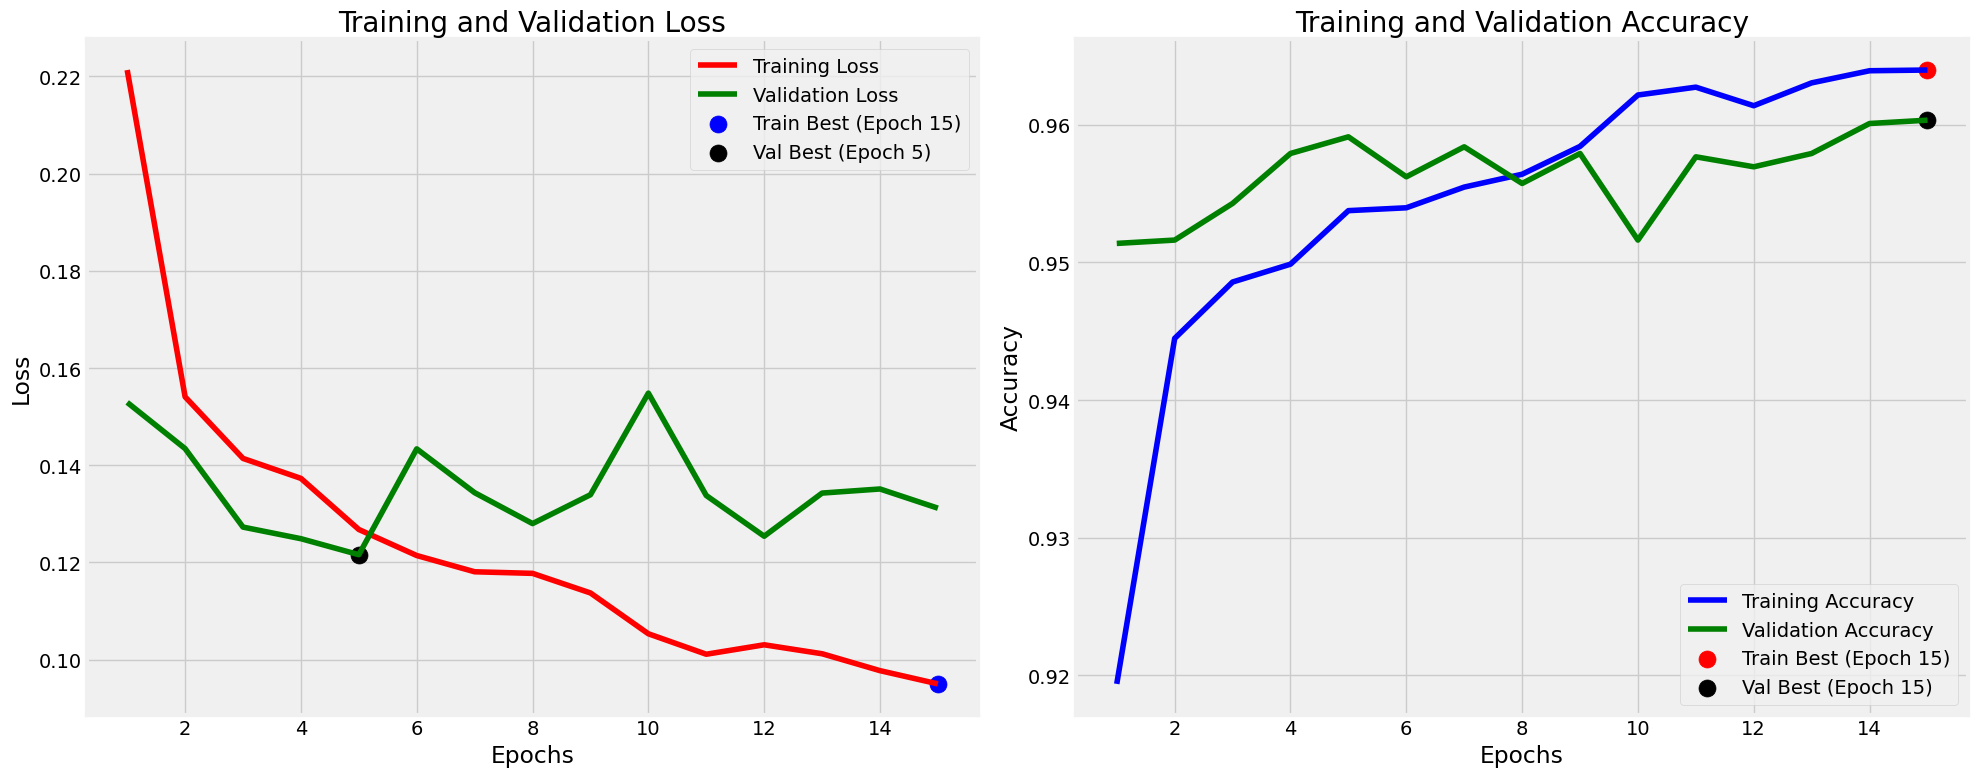

In [ ]:
# Ekstraksi data dari history
train_accuracy = history2.history['accuracy']
train_loss = history2.history['loss']
val_accuracy = history2.history['val_accuracy']
val_loss = history2.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 2 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 611ms/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.005
Epoch: 20

--- Informasi dari History 2 ---
Best Val Acc: 0.9603 (Epoch 15)
Testing Accuracy: 0.9560
Total Prediction Time: 27.46 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

 Parasitized      0.968     0.943     0.955      2067
  Uninfected      0.945     0.969     0.957      2067

    accuracy                          0.956      4134
   macro avg      0.956     0.956     0.956      4134
weighted avg      0.956     0.956     0.956      4134




--- Confusion Matrix ---


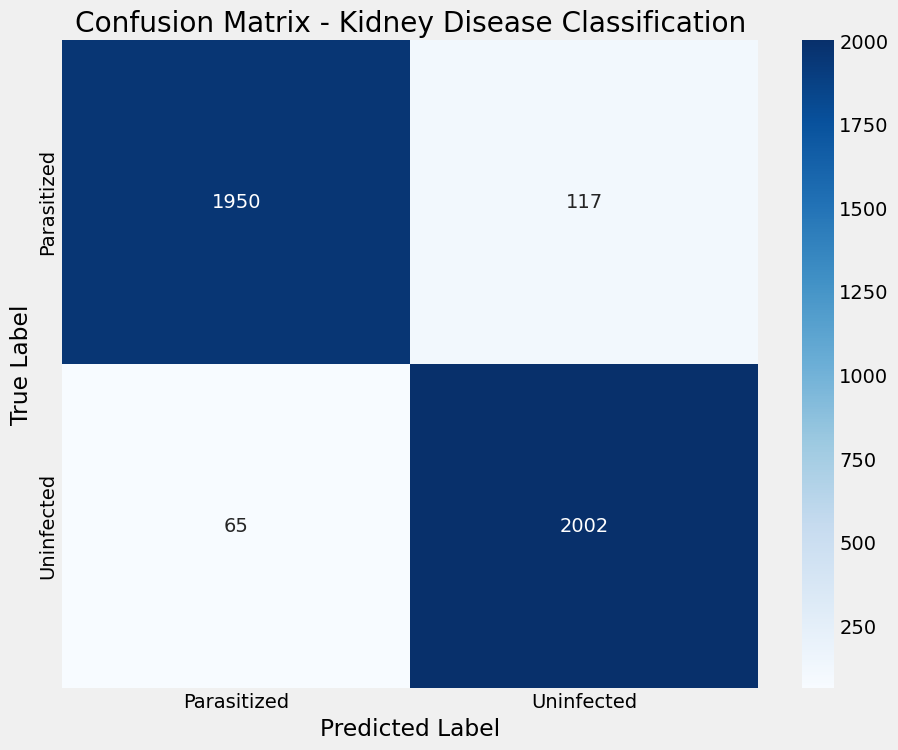

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 2 ---


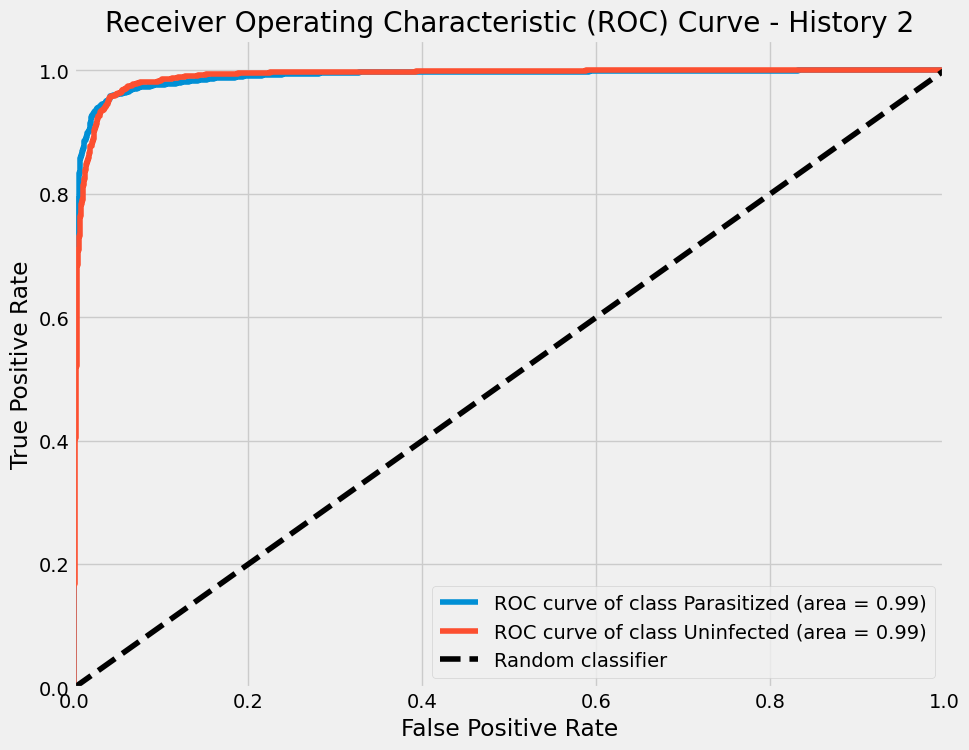

In [ ]:
print("\n--- ROC AUC for History 2 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 2')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 3

In [12]:
# Parameter Initialization
learning_rate = 0.001
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# Trains the model for a fixed number of epochs (dataset iterations).
history3 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8854 - loss: 0.3353
Epoch 1: val_accuracy improved from None to 0.94388, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9160 - loss: 0.2366 - val_accuracy: 0.9439 - val_loss: 0.1646
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9357 - loss: 0.1700
Epoch 2: val_accuracy improved from 0.94388 to 0.94920, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9386 - loss: 0.1675 - val_accuracy: 0.9492 - val_loss: 0.1492
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9430 - loss: 0.1525
Epoch 3: val_accuracy improved from 0.94920 to 0.95283, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9440 - loss: 0.1504 - val_accurac

# Evaluation Metric 3

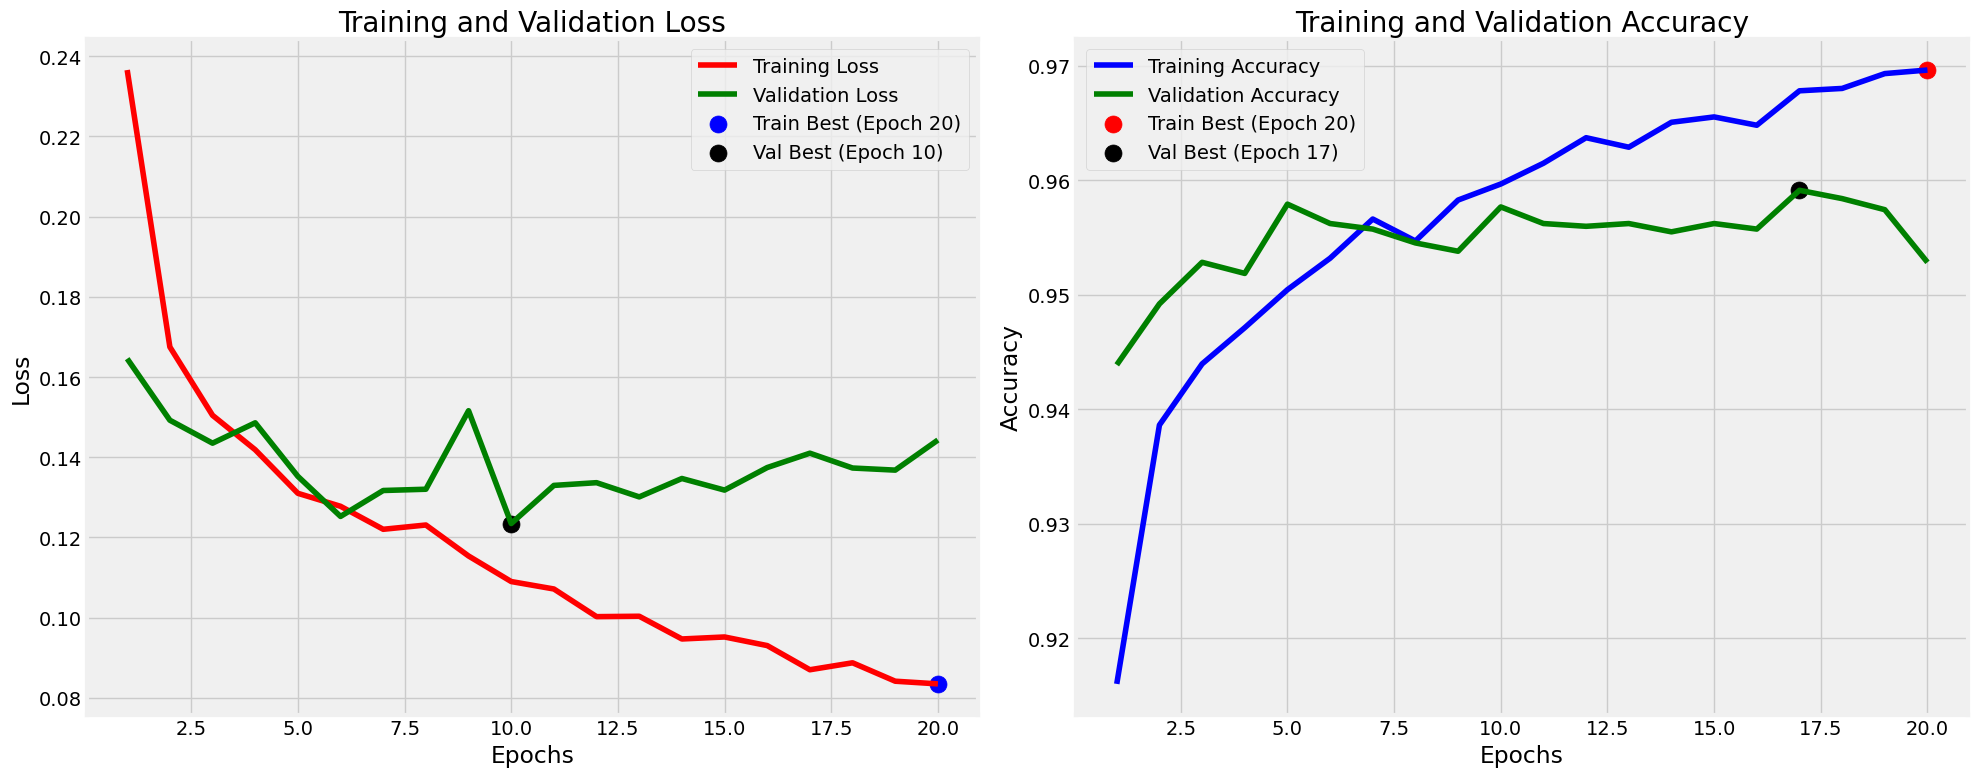

In [13]:
# Ekstraksi data dari history
train_accuracy = history3.history['accuracy']
train_loss = history3.history['loss']
val_accuracy = history3.history['val_accuracy']
val_loss = history3.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 3 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 573ms/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.001
Epoch: 20

--- Informasi dari History 3 ---
Best Val Acc: 0.9591 (Epoch 17)
Testing Accuracy: 0.9555
Total Prediction Time: 25.71 seconds


In [15]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

 Parasitized      0.968     0.942     0.955      2067
  Uninfected      0.944     0.969     0.956      2067

    accuracy                          0.955      4134
   macro avg      0.956     0.955     0.955      4134
weighted avg      0.956     0.955     0.955      4134




--- Confusion Matrix ---


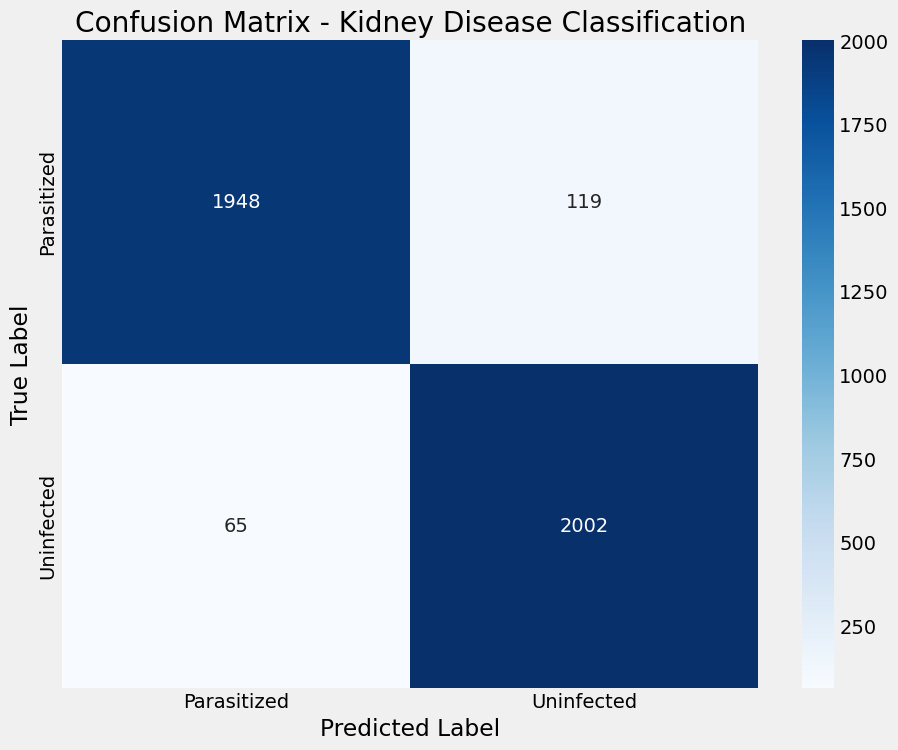

In [16]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 3 ---


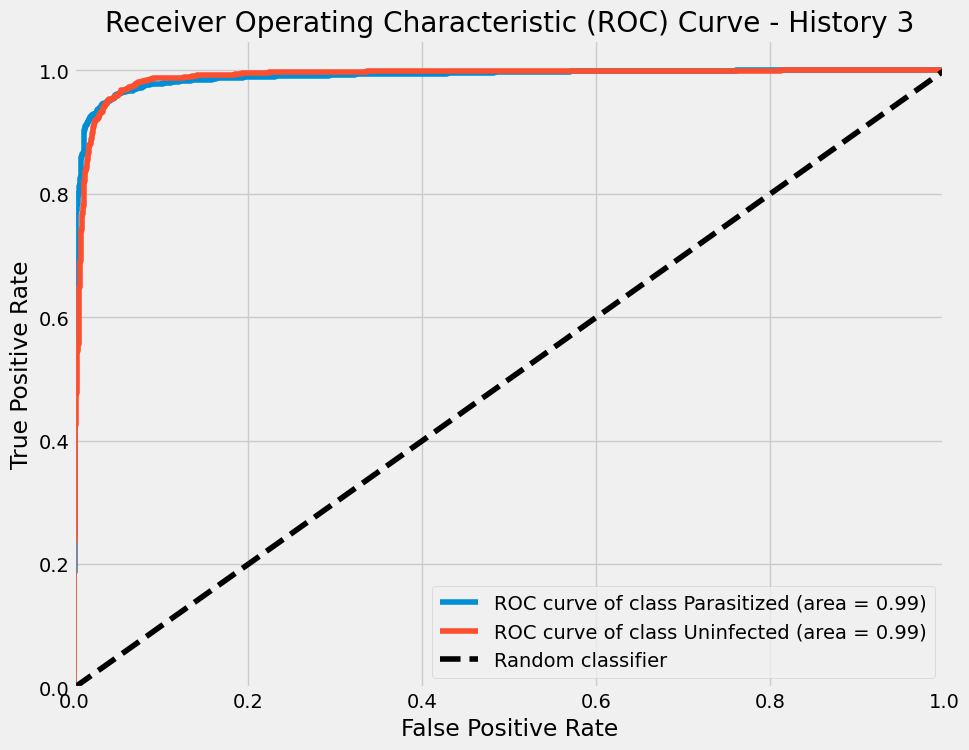

In [17]:
print("\n--- ROC AUC for History 3 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 3')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 4

In [18]:
# Parameter Initialization
learning_rate = 0.0005
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# Trains the model for a fixed number of epochs (dataset iterations).
history4 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9604 - loss: 0.1102
Epoch 1: val_accuracy improved from None to 0.96251, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9604 - loss: 0.1080 - val_accuracy: 0.9625 - val_loss: 0.1279
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9628 - loss: 0.1011
Epoch 2: val_accuracy did not improve from 0.96251
151/151 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9621 - loss: 0.1025 - val_accuracy: 0.9594 - val_loss: 0.1287
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9624 - loss: 0.1004
Epoch 3: val_accuracy did not improve from 0.96251
151/151 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9646 - loss: 0.0953 - val_accuracy: 0.9594 - val_loss: 0.1288
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9647 - loss: 0.0963
Epoch 4: val_accuracy did not improve from 0.96251
151/151 ━━━━━━━

# Evaluation Metric 4

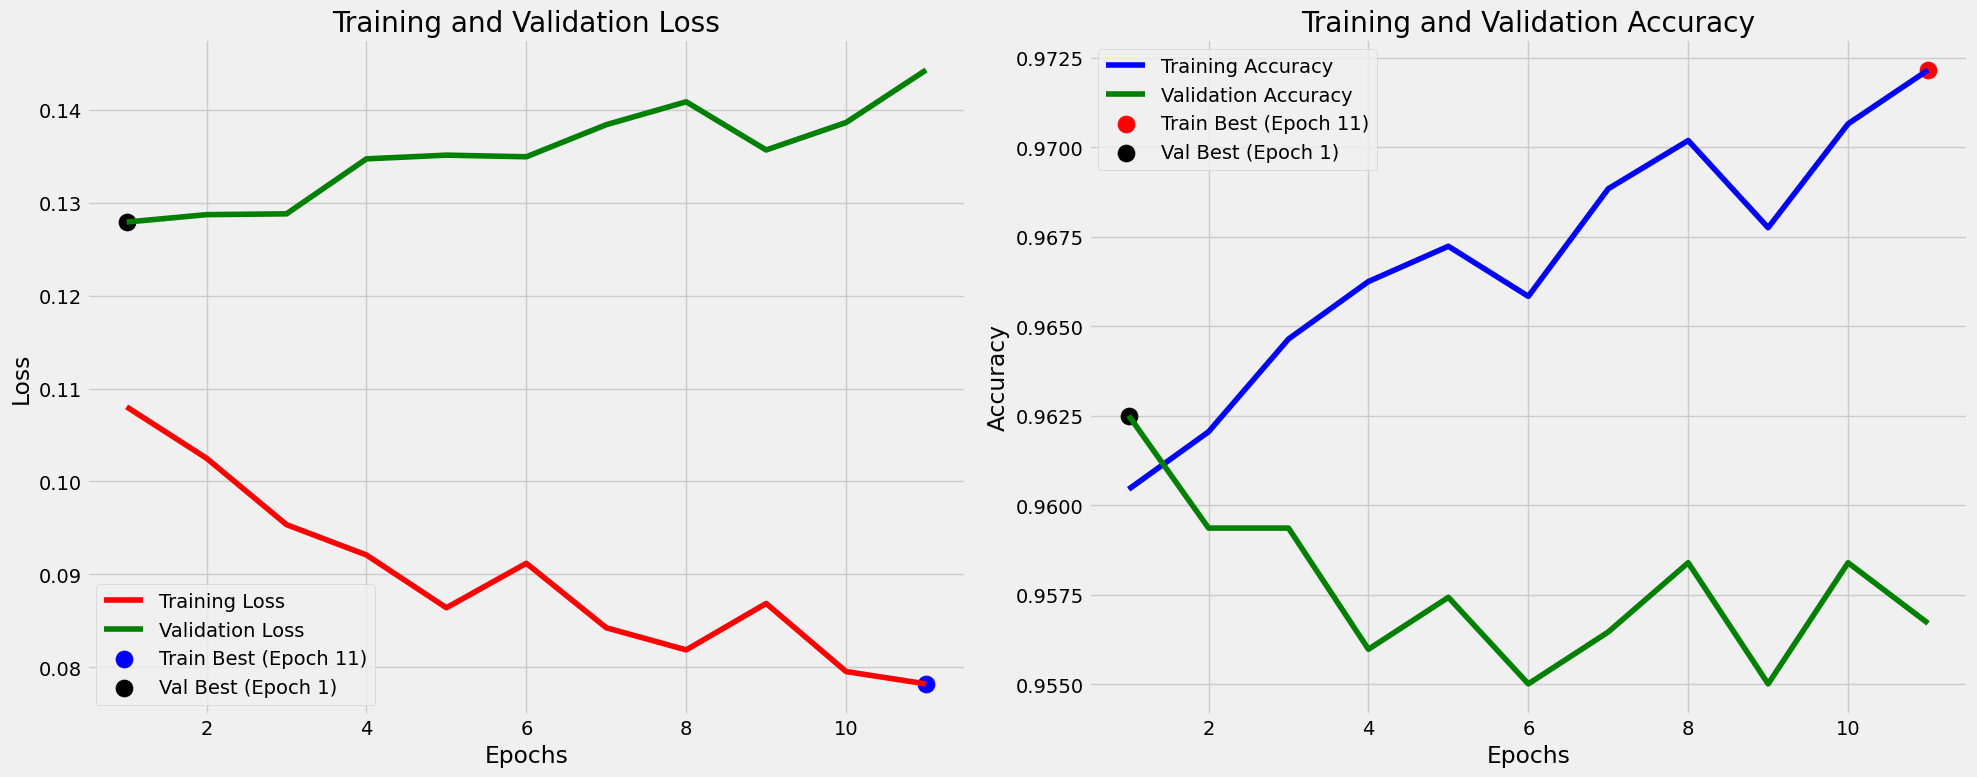

In [19]:
# Ekstraksi data dari history
train_accuracy = history4.history['accuracy']
train_loss = history4.history['loss']
val_accuracy = history4.history['val_accuracy']
val_loss = history4.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 4 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 569ms/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.0005
Epoch: 20

--- Informasi dari History 4 ---
Best Val Acc: 0.9625 (Epoch 1)
Testing Accuracy: 0.9565
Total Prediction Time: 26.48 seconds


In [21]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

 Parasitized      0.970     0.942     0.956      2067
  Uninfected      0.944     0.971     0.957      2067

    accuracy                          0.956      4134
   macro avg      0.957     0.956     0.956      4134
weighted avg      0.957     0.956     0.956      4134




--- Confusion Matrix ---


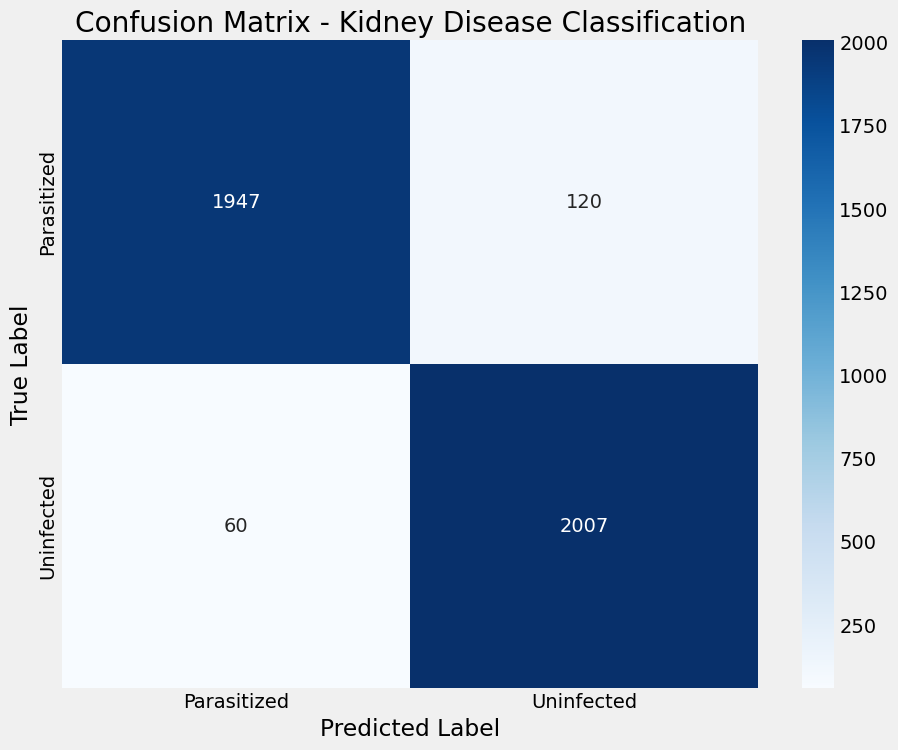

In [22]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 4 ---


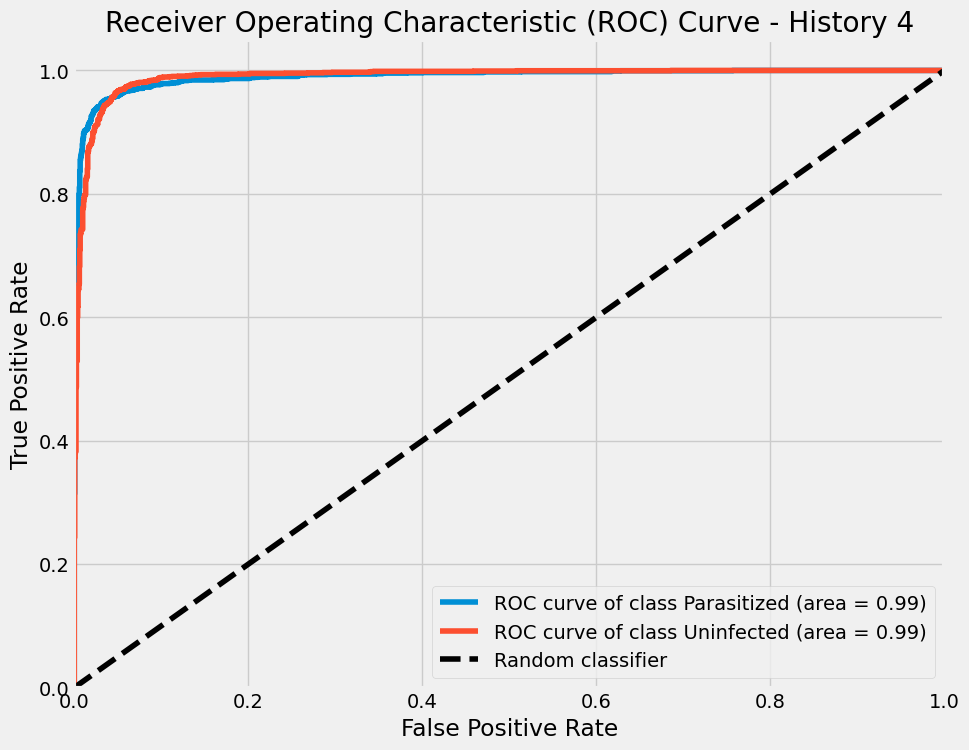

In [23]:
print("\n--- ROC AUC for History 4 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 4')
plt.legend(loc="lower right")
plt.show()

# Prediction on New Image (InceptionV3)

In [27]:
# --- 1. Persiapan Model ---
InceptionV3_model.save("malaria_cell_classification_InceptionV3.keras")
# Memuat model yang sudah dilatih dari file .keras
loaded_model = tf.keras.models.load_model("/content/malaria_cell_classification_InceptionV3.keras", compile=True)
# Mengompilasi ulang model untuk memastikan optimizer dan fungsi loss siap digunakan
loaded_model.compile(Adamax(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# Fungsi Utama untuk Visualisasi Grad-CAM
def visualize_grad_cam(model, image_path, class_labels):

  image = Image.open(image_path).convert('RGB') # Convert image to RGB

  # --- 2. Preprocessing (Penyesuaian Gambar) ---
  # Mengubah ukuran gambar ke 224x224 (standar MobileNetV3)
  img = image.resize((224, 224))
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  original_img = img_array.copy()
  img_array = tf.expand_dims(img_array, 0)

  # Apply the custom preprocessing function with CLAHE
  preprocessed_img_array = preprocess_input(img_array)

  # --- 3. Inferensi / Prediksi
  # Meminta model menebak gambar
  predictions = model.predict(preprocessed_img_array)
  predicted_class_idx = np.argmax(predictions)
  predicted_class = class_labels[predicted_class_idx]
  confidence = 100 * np.max(predictions)

  # Menampilkan log hasil prediksi di konsol
  print(f"Image path: {image_path}")
  print(f"Predicted class: {predicted_class}")
  print(f"Confidence: {confidence:.2f}%")
  print("\nAll class probabilities:")
  for i, prob in enumerate(predictions[0]):
    print(f"{class_labels[i]}: {100 * prob:.2f}%")

  # --- 4. Persiapan Struktur GRAD-CAM (Pembedahan Model) ---
  # Mengambil 'backbone' model (MobileNetV3Large) yang ada di layer pertama
  base_model_feature_extractor = model.layers[0]
  # Mengambil output dari layer konvolusi terakhir sebagai peta fitur (feature map)
  feature_map_output_tensor = base_model_feature_extractor.output

  # Membuat model sub-bagian untuk mengekstrak fitur visual
  feature_map_model = tf.keras.Model(
    inputs = base_model_feature_extractor.input,
    outputs = feature_map_output_tensor)

  # Menyiapkan input untuk bagian klasifikasi (biasanya berukuran 7x7x960)
  classifier_input_shape = feature_map_output_tensor.shape[1:]
  classifier_input = tf.keras.Input(shape=classifier_input_shape)

  # Menyambungkan kembali lapisan klasifikasi (Dense/Pooling) ke input baru
  x = classifier_input
  for layer in model.layers[1:]:
    x = layer(x)
  classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

  # --- 5. Perhitungan Gradien (Mencari Bagian Penting) ---
  # Menggunakan GradientTape untuk merekam operasi matematis demi mendapatkan gradien
  with tf.GradientTape() as tape:
    # 1. Dapatkan peta fitur dari gambar
    feature_map_output = feature_map_model(preprocessed_img_array)
    tape.watch(feature_map_output) # Pantau perubahan pada peta fitur ini

    # 2. Masukkan ke klasifikasi untuk dapat prediksi akhir
    predictions_from_classifier = classifier_model(feature_map_output)
    class_channel = predictions_from_classifier[:, predicted_class_idx]

  # Hitung seberapa sensitif skor prediksi terhadap setiap pixel di peta fitur
  grads = tape.gradient(class_channel, feature_map_output)
  # Ambil rata-rata gradien (Global Average Pooling) untuk menentukan bobot tiap channel
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # --- 6. Pembuatan Heatmap (Peta Panas) ---
  # Kalikan peta fitur dengan bobot gradien untuk melihat area mana yang paling "berpengaruh"
  last_conv_layer_output_for_heatmap = feature_map_output[0]
  heatmap = last_conv_layer_output_for_heatmap @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap) # Hilangkan dimensi yang tidak perlu

  # Normalisasi: Ubah nilai heatmap agar berada di rentang 0 sampai 1 (ReLu + Max)
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
  heatmap = heatmap.numpy()

  # --- 7. VISUALISASI AKHIR (Pengaggabungan)
  # Resize heatmap agar ukurannya sama dengan gambar asli (224 x 224)
  original_img_uint8 = np.uint8(original_img)
  heatmap = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  # Beri warna pada heatmap (Biru = Dingin/Biasa, Merah = Panas/Penting)
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET) # Ubah ke skala 0-255

  # Timpa heatmap ke gambar asli dengan transparansi (40% heatmap)
  superimposed_img = heatmap * 0.4 + original_img_uint8
  superimposed_img = np.uint8(255 * (superimposed_img / np.max(superimposed_img)))

  # Tampilkan hasil secara berdampingan: Gambar Asli vs Lokasi Deteksi AI
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(img);
  plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(superimposed_img)
  plt.title(f"Grad-CAM for {predicted_class}")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  return predicted_class, confidence, superimposed_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Image path: /kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png
Predicted class: Parasitized
Confidence: 99.99%

All class probabilities:
Parasitized: 99.99%
Uninfected: 0.01%


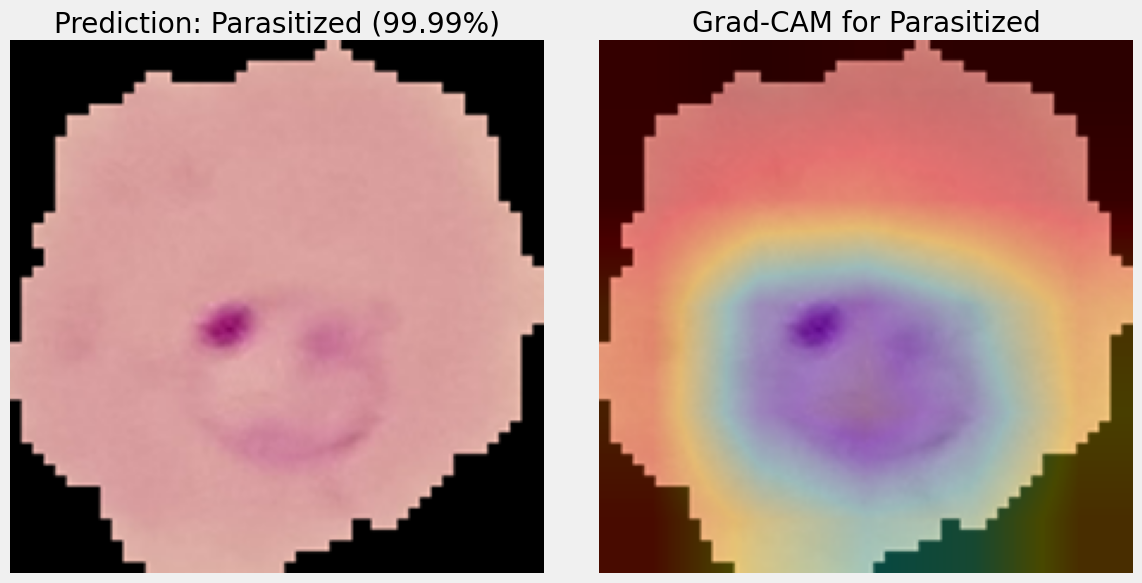

In [28]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Parasitized", "C100P61ThinF_IMG_20150918_144104_cell_162.png")
class_labels_for_test = ["Parasitized", "Uninfected"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Image path: /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_128.png
Predicted class: Uninfected
Confidence: 99.99%

All class probabilities:
Parasitized: 0.01%
Uninfected: 99.99%


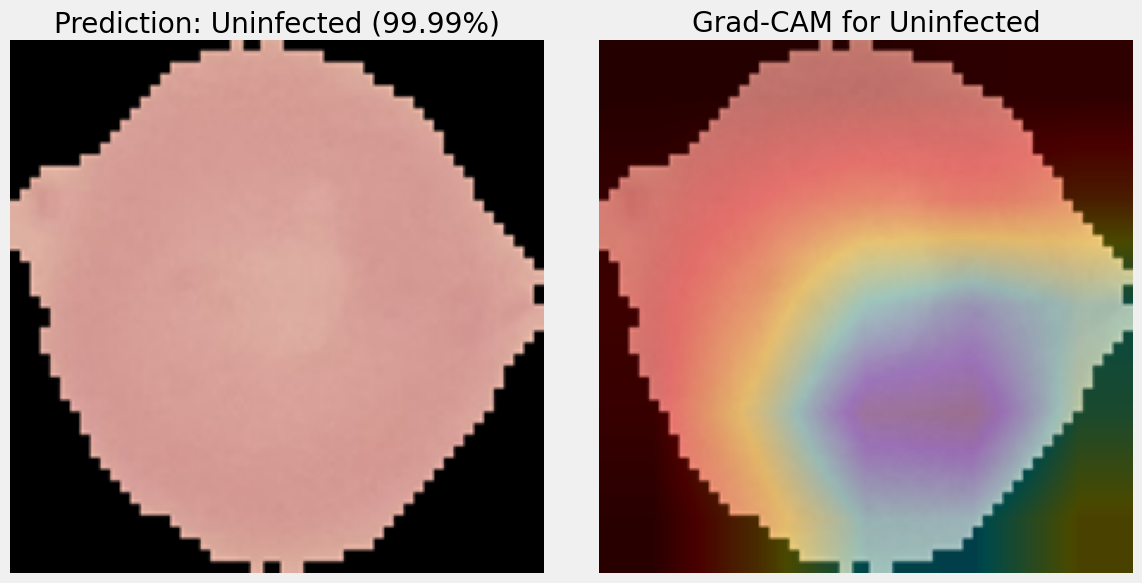

In [29]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Uninfected", "C100P61ThinF_IMG_20150918_144104_cell_128.png")
class_labels_for_test = ["Parasitized", "Uninfected"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)